# Import

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [172]:
from google.colab import drive

drive.mount('/content/drive', force_remount = False)

drugs = pd.read_csv('/content/drive/MyDrive/M1 Project Proposal/data/drugs.csv')
#The drugs.csv file is within the data file of the google drive, easiest way is to download it and upload to the current runtime

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [173]:
drugs.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


# Preprocessing

##Keane

In [174]:
drugs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   category                                     1988 non-null   object 
 1   medicine_name                                1988 non-null   object 
 2   therapeutic_area                             1703 non-null   object 
 3   common_name                                  1984 non-null   object 
 4   active_substance                             1987 non-null   object 
 5   product_number                               1988 non-null   int64  
 6   patient_safety                               1988 non-null   bool   
 7   authorisation_status                         1987 non-null   object 
 8   atc_code                                     1960 non-null   object 
 9   additional_monitoring                        1988 non-null   bool   
 10  

In [175]:
drugs['decision_date'] = pd.to_datetime(drugs['decision_date'], errors='coerce')
drugs['approval_year'] = drugs['decision_date'].dt.year
drugs_approved_per_year = drugs['approval_year'].value_counts().sort_index()
display(drugs_approved_per_year.tail(10))

,count
approval_year,
2014.0,31
2015.0,30
2016.0,33
2017.0,37
2018.0,54
2019.0,59
2020.0,100
2021.0,381
2022.0,794


##Prepare Missingness Data

Create a new DataFrame that indicates the presence (0) or absence (1) of data for relevant regulatory columns in the `drugs` DataFrame. This will transform the dataset into a format suitable for clustering based on missingness patterns.

In [176]:
missing_cols = drugs.columns[drugs.isnull().any()].tolist()

missingness_df = drugs[missing_cols].isnull().astype(int)
display(missingness_df.head())
display(missingness_df.tail())

,therapeutic_area,common_name,active_substance,authorisation_status,atc_code,marketing_authorisation_date,date_of_refusal_of_marketing_authorisation,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,revision_date,approval_year
0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


,therapeutic_area,common_name,active_substance,authorisation_status,atc_code,marketing_authorisation_date,date_of_refusal_of_marketing_authorisation,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,revision_date,approval_year
1983,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1984,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1985,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1986,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1987,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0


##Brian

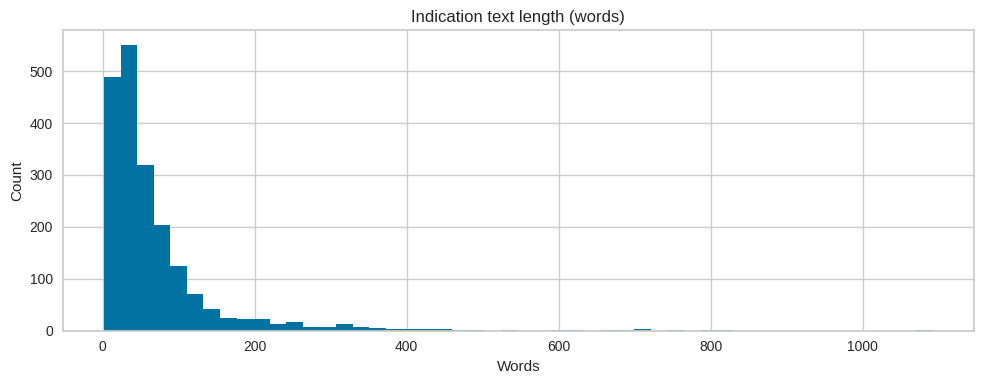

count    1976.000000
mean       70.555668
std        93.732244
min         2.000000
25%        24.000000
50%        42.000000
75%        80.000000
max      1092.000000
Name: condition_indication, dtype: float64
Top 10 longest indications:
    medicine_name authorisation_status  \
360        Viread           authorised   
314       Noxafil           authorised   
461      Keytruda           authorised   
603     RoActemra           authorised   
256       Yuflyma           authorised   
176        Hefiya           authorised   
621        Idacio           authorised   
284      Amgevita           authorised   
591       Imraldi           authorised   
6        Hukyndra           authorised   

                                  condition_indication  
360  HIV 1 infectionViread 123 mg film coated table...  
314  Noxafil gastro-resistant tablets are indicated...  
461  MelanomaKeytruda as monotherapy is indicated f...  
603  RoActemra, in combination with methotrexate (M...  
256  Rheumato

In [177]:
ind_words = drugs["condition_indication"].dropna().astype(str).str.split().str.len()

plt.figure(figsize=(10,4))
plt.hist(ind_words, bins=50)
plt.title("Indication text length (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(ind_words.describe())
print("Top 10 longest indications:")
print(drugs.loc[ind_words.sort_values(ascending=False).head(10).index,
             ["medicine_name","authorisation_status","condition_indication"]].head(10))

In [178]:
import spacy

drugs['condition_indication'] = drugs['condition_indication'].fillna('')

nlp = spacy.load("en_core_web_sm") # nlp processing for improved readability for the computer.

def clean_text(text):
    text = str(text).lower()
    replacements = { # condition_indication contains special symbols in words such as CD30+
        '+': 'plus', '%': 'percent', '>': 'greater', '<': 'less', '&': 'and', '/': 'or'  # 'and/or' becomes 'andor'
    }
    for symbol, word in replacements.items():
        text = text.replace(symbol, word)
    text = text.replace('-', 'minus') # special handling for the '-' symbol, as it can be used both as a minus sign and a hyphen
    doc = nlp(text)
    clean_tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct
    ]
    return " ".join(clean_tokens)

drugs["condition_indication_cleaned"] = drugs["condition_indication"].apply(clean_text)
print(f"Original: {drugs['condition_indication'].iloc[0][:100]}")
print(f"Cleaned:  {drugs['condition_indication_cleaned'].iloc[0][:100]}")

Original: Hodgkin lymphomaAdcetris is indicated for adult patients with previously untreated CD30+ Stage IV Ho
Cleaned:  hodgkin lymphomaadcetris indicate adult patient previously untreated cd30plus stage iv hodgkin lymph


In [179]:
from sklearn.feature_extraction.text import TfidfVectorizer

limit_text = int(ind_words.quantile(0.95))
print(f"max_features cutoff word length: {limit_text} words")

# vectorizes the cleaned condition_indication from the previous step for ML modeling later
vectorizer = TfidfVectorizer(max_features = limit_text, min_df = 0.01, max_df = 0.95) #being generous with 500 words
X_tfidf = vectorizer.fit_transform(drugs["condition_indication_cleaned"])

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns = vectorizer.get_feature_names_out())

print("\n--- Vectorization Result ---")
print(f"Matrix Shape: {X_tfidf.shape} (Rows, Unique Words)")
print("Sample of the Vectorized Data:")
print(tfidf_df.iloc[:5, :10])

max_features cutoff word length: 227 words

--- Vectorization Result ---
Matrix Shape: (1988, 227) (Rows, Unique Words)
Sample of the Vectorized Data:
         12   18  accord  acid    active  acute  adequate  adequately  \
0  0.000000  0.0     0.0   0.0  0.000000    0.0       0.0         0.0   
1  0.000000  0.0     0.0   0.0  0.000000    0.0       0.0         0.0   
2  0.000000  0.0     0.0   0.0  0.000000    0.0       0.0         0.0   
3  0.323005  0.0     0.0   0.0  0.000000    0.0       0.0         0.0   
4  0.000000  0.0     0.0   0.0  0.237125    0.0       0.0         0.0   

   adjunct  adjunctive  
0      0.0         0.0  
1      0.0         0.0  
2      0.0         0.0  
3      0.0         0.0  
4      0.0         0.0  


In [180]:
# For more clarity in cluster visualizations, we used TruncatedSVD to reduce noise in the TF-IDF
# This will also help with t-SNE run speeds downstream.

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components = 50, random_state = 999)
X_svd = svd.fit_transform(X_tfidf)

##Rahul

In [181]:
# Basic missingness + outcome distribution
key_cols = ["therapeutic_area", "authorisation_status"]
missing_summary = drugs[key_cols].isna().mean().sort_values(ascending=False).to_frame("missing_rate")
print("\nMissingness (key fields):")
display(missing_summary)

print("\nOutcome counts:")
display(drugs["authorisation_status"].value_counts(dropna=False))


Missingness (key fields):


,missing_rate
therapeutic_area,0.143360
authorisation_status,0.000503



Outcome counts:


,count
authorisation_status,
authorised,1573
withdrawn,357
refused,57
NaN,1


In [182]:
df_q1 = drugs.copy()

# Drop rows missing outcome (only ~1 row in this dataset)
df_q1 = df_q1.dropna(subset=["authorisation_status"]).copy()

# Normalize outcome labels
df_q1["authorisation_status"] = df_q1["authorisation_status"].astype(str).str.strip().str.lower()

allowed_outcomes = {"authorised", "withdrawn", "refused"}
unknown_outcomes = sorted(set(df_q1["authorisation_status"].unique()) - allowed_outcomes)
if unknown_outcomes:
    print("WARNING: Unknown outcomes found:", unknown_outcomes)

# Keep only the three outcomes we care about
df_q1 = df_q1[df_q1["authorisation_status"].isin(allowed_outcomes)].copy()

print("df_q1 shape:", df_q1.shape)
print("\nOutcome distribution in df_q1:")
display(df_q1["authorisation_status"].value_counts())
display(df_q1["authorisation_status"].value_counts(normalize=True).rename("proportion"))

df_q1 shape: (1987, 30)

Outcome distribution in df_q1:


,count
authorisation_status,
authorised,1573
withdrawn,357
refused,57


,proportion
authorisation_status,
authorised,0.791646
withdrawn,0.179668
refused,0.028686


In [183]:
import re

def clean_area_string(s: str) -> str:
    """Normalize therapeutic area label spacing/casing without over-normalizing semantics."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

# Track A: as-is (single label)
df_A = df_q1.copy()
df_A["therapeutic_area_clean"] = df_A["therapeutic_area"].apply(clean_area_string)

# Drop missing therapeutic area
df_A = df_A[df_A["therapeutic_area_clean"].notna()].copy()

print("Track A shape:", df_A.shape)
print("Unique therapeutic_area (A):", df_A["therapeutic_area_clean"].nunique())

# Track B: split multi-label + explode
def split_areas(s: str, delimiter=";"):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return []
    s = clean_area_string(s)
    if not s:
        return []
    parts = [p.strip() for p in s.split(delimiter)]
    parts = [re.sub(r"\s+", " ", p) for p in parts if p.strip()]
    # Deduplicate while preserving order
    seen = set()
    out = []
    for p in parts:
        if p not in seen:
            out.append(p)
            seen.add(p)
    return out

df_B = df_q1.copy()
df_B["therapeutic_area_list"] = df_B["therapeutic_area"].apply(split_areas)

# Drop rows that have empty lists (missing therapeutic area)
df_B = df_B[df_B["therapeutic_area_list"].map(len) > 0].copy()

# Explode
df_B = df_B.explode("therapeutic_area_list", ignore_index=True)
df_B["therapeutic_area_clean"] = df_B["therapeutic_area_list"].apply(clean_area_string)
df_B.drop(columns=["therapeutic_area_list"], inplace=True)

print("Track B shape (after explode):", df_B.shape)
print("Unique therapeutic_area (B):", df_B["therapeutic_area_clean"].nunique())

Track A shape: (1703, 31)
Unique therapeutic_area (A): 669
Track B shape (after explode): (2941, 31)
Unique therapeutic_area (B): 546


In [184]:
def get_high_volume_areas(df_in: pd.DataFrame, area_col: str, min_n: int = 30):
    counts = df_in[area_col].value_counts()
    high = counts[counts >= min_n]
    return high, counts

MIN_N = 30

high_A, counts_A = get_high_volume_areas(df_A, "therapeutic_area_clean", min_n=MIN_N)
high_B, counts_B = get_high_volume_areas(df_B, "therapeutic_area_clean", min_n=MIN_N)

print(f"\nTop 15 areas by volume — Track A (as-is). MIN_N={MIN_N}")
display(counts_A.head(15).to_frame("n"))

print(f"\nTop 15 areas by volume — Track B (exploded). MIN_N={MIN_N}")
display(counts_B.head(15).to_frame("n"))

print(f"\n# high-volume areas (A): {len(high_A)}")
print(f"# high-volume areas (B): {len(high_B)}")


Top 15 areas by volume — Track A (as-is). MIN_N=30


,n
therapeutic_area_clean,
"Diabetes Mellitus, Type 2",73
HIV Infections,71
Hypertension,47
Diabetes Mellitus,37
"Pulmonary Disease, Chronic Obstructive",30
Multiple Myeloma,22
"Hepatitis C, Chronic",22
Parkinson Disease,20
Epilepsy,19



Top 15 areas by volume — Track B (exploded). MIN_N=30


,n
therapeutic_area_clean,
"Diabetes Mellitus, Type 2",77
HIV Infections,74
Breast Neoplasms,63
"Carcinoma, Non-Small-Cell Lung",61
Immunization,52
"Arthritis, Rheumatoid",51
Hypertension,47
Myocardial Infarction,42
Diabetes Mellitus,39



# high-volume areas (A): 5
# high-volume areas (B): 17


In [185]:
def build_profiles(df_in: pd.DataFrame, area_col: str, outcome_col: str, min_n: int = 30):
    # counts table: rows=area, cols=outcomes
    ct = pd.crosstab(df_in[area_col], df_in[outcome_col])

    # ensure all outcomes exist as columns
    for oc in ["authorised", "withdrawn", "refused"]:
        if oc not in ct.columns:
            ct[oc] = 0
    ct = ct[["authorised", "withdrawn", "refused"]]

    ct["n_total"] = ct.sum(axis=1)

    # Filter high-volume
    ct = ct[ct["n_total"] >= min_n].copy()

    # proportions
    for oc in ["authorised", "withdrawn", "refused"]:
        ct[f"p_{oc}"] = ct[oc] / ct["n_total"]

    # Sort by volume descending
    ct = ct.sort_values("n_total", ascending=False)
    return ct

profiles_A = build_profiles(df_A, "therapeutic_area_clean", "authorisation_status", min_n=MIN_N)
profiles_B = build_profiles(df_B, "therapeutic_area_clean", "authorisation_status", min_n=MIN_N)

print("\nProfiles A (head):")
display(profiles_A.head(10))

print("\nProfiles B (head):")
display(profiles_B.head(10))

# Save these for sharing / report later
# profiles_A.to_csv(os.path.join(OUT_DIR, f"profiles_A_min{MIN_N}.csv"))
# profiles_B.to_csv(os.path.join(OUT_DIR, f"profiles_B_min{MIN_N}.csv"))


Profiles A (head):


authorisation_status,authorised,withdrawn,refused,n_total,p_authorised,p_withdrawn,p_refused
therapeutic_area_clean,,,,,,,
"Diabetes Mellitus, Type 2",57,16,0,73,0.780822,0.219178,0.000000
HIV Infections,61,10,0,71,0.859155,0.140845,0.000000
Hypertension,30,17,0,47,0.638298,0.361702,0.000000
Diabetes Mellitus,29,7,1,37,0.783784,0.189189,0.027027
"Pulmonary Disease, Chronic Obstructive",27,3,0,30,0.900000,0.100000,0.000000



Profiles B (head):


authorisation_status,authorised,withdrawn,refused,n_total,p_authorised,p_withdrawn,p_refused
therapeutic_area_clean,,,,,,,
"Diabetes Mellitus, Type 2",61,16,0,77,0.792208,0.207792,0.000000
HIV Infections,62,12,0,74,0.837838,0.162162,0.000000
Breast Neoplasms,51,10,2,63,0.809524,0.158730,0.031746
"Carcinoma, Non-Small-Cell Lung",47,13,1,61,0.770492,0.213115,0.016393
Immunization,25,27,0,52,0.480769,0.519231,0.000000
"Arthritis, Rheumatoid",40,10,1,51,0.784314,0.196078,0.019608
Hypertension,30,17,0,47,0.638298,0.361702,0.000000
Myocardial Infarction,24,18,0,42,0.571429,0.428571,0.000000
Diabetes Mellitus,31,7,1,39,0.794872,0.179487,0.025641


##Alex

In [186]:
df = drugs.copy()
df.head()

date_cols = [
    "marketing_authorisation_date",
    "date_of_refusal_of_marketing_authorisation",
    "date_of_opinion",
    "decision_date",
    "first_published",
    "revision_date"
]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)

In [187]:
yn_cols = [
    "Patient safety", "Additional monitoring", "Generic", "Biosimilar",
    "Conditional approval", "Exceptional circumstances",
    "Accelerated assessment", "Orphan medicine"
]

for c in yn_cols:
    if c in df.columns:
        df[c] = (df[c].astype(str).str.strip().str.lower()
                   .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))

In [188]:
flag_cols = [
    "patient_safety", "additional_monitoring", "generic", "biosimilar",
    "conditional_approval", "exceptional_circumstances",
    "accelerated_assessment", "orphan_medicine"
]

flag_rates = df[flag_cols].mean().sort_values(ascending=False)
print(flag_rates)

additional_monitoring        0.194668
generic                      0.158451
orphan_medicine              0.081489
biosimilar                   0.046278
exceptional_circumstances    0.024145
conditional_approval         0.024145
accelerated_assessment       0.024145
patient_safety               0.005533
dtype: float64


 # Can medicines be grouped by patterns of missing regulatory data that reflect different approval eras or regulatory contexts? - Keane

Motivation from EDA: Missingness is structured rather than random, with consistent sparsity patterns across subsets of drugs.

Who Benefits: Regulatory agencies can see indications of systematic documentation gaps and assess how data completeness has evolved over time.


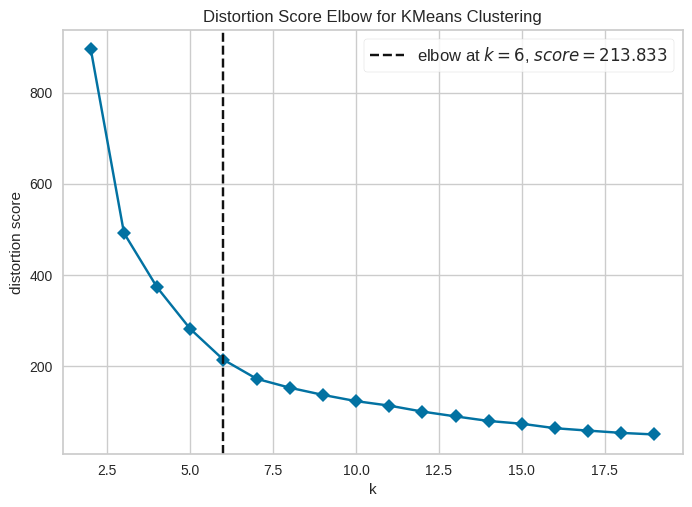

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [189]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(
    clustering, k=(2, 20), metric='distortion', timings=False, random_state=42
)

visualizer.fit(missingness_df)
visualizer.show()

Association Rules

Hierarchical Clustering

Feature Normalization

## K-Means Clustering

K-Means on missingness data using the optimal number of clusters identified. Assign labels back to the original `drugs` DataFrame to group medicines by their missing data patterns.



Initialize a KMeans model with 3 clusters, fit it to the `missingness_df` to cluster medicines based on their missing data patterns, and then assign the resulting cluster labels to a new column in the original `drugs` DataFrame.



In [190]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
missingness_clusters = kmeans.fit_predict(missingness_df)
drugs['missingness_cluster'] = missingness_clusters
display(drugs.head())

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,decision_date,revision_number,condition_indication,species,first_published,revision_date,url,approval_year,condition_indication_cleaned,missingness_cluster
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2022.0,hodgkin lymphomaadcetris indicate adult patien...,2
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,treatment adult paediatric patient confirm dia...,2
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,ebvallo indicate monotherapy treatment adult p...,2
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,ronapreve indicate treatment covidminus19 adul...,2
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,plaque psoriasiscosentyx indicate treatment mo...,2


In [191]:
drugs['decision_date'] = pd.to_datetime(drugs['decision_date'], errors='coerce')
drugs['approval_year'] = drugs['decision_date'].dt.year

In [192]:
avg_approval_year_per_cluster = drugs.groupby('missingness_cluster')['approval_year'].mean()

missingness_df['missingness_cluster'] = drugs['missingness_cluster']
mean_missingness_per_cluster = missingness_df.groupby('missingness_cluster').mean()

print("\nAverage Approval Year per Cluster:")
print(avg_approval_year_per_cluster)

print("\nMean Missingness Percentage per Cluster for each Regulatory Column:")
print(mean_missingness_per_cluster)


Average Approval Year per Cluster:
missingness_cluster
0    2018.028346
1    2020.261905
2    2021.801811
3    2017.902098
4            NaN
5    2012.755556
Name: approval_year, dtype: float64

Mean Missingness Percentage per Cluster for each Regulatory Column:
                     therapeutic_area  common_name  active_substance  \
missingness_cluster                                                    
0                            0.001575     0.001575          0.000000   
1                            1.000000     0.007937          0.000000   
2                            0.003018     0.000000          0.000000   
3                            1.000000     0.006993          0.000000   
4                            0.244444     0.022222          0.022222   
5                            0.022222     0.000000          0.000000   

                     authorisation_status  atc_code  \
missingness_cluster                                   
0                                0.000000  0.00157

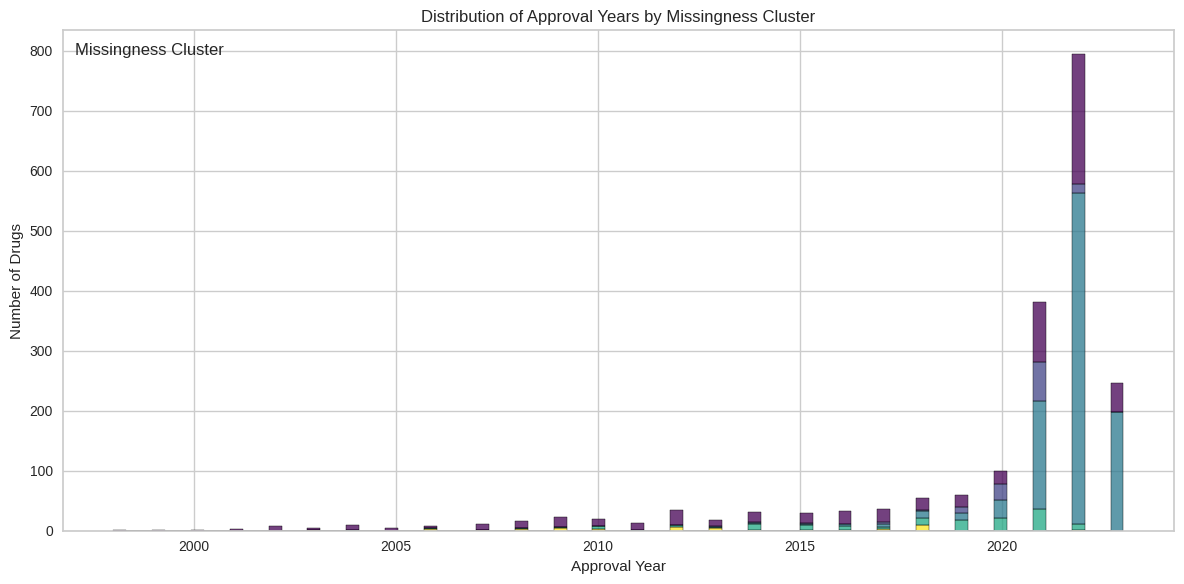

In [193]:
plt.figure(figsize=(12, 6))
sns.histplot(data=drugs, x='approval_year', hue='missingness_cluster', multiple='stack', palette='viridis', kde=False)
plt.title('Distribution of Approval Years by Missingness Cluster')
plt.xlabel('Approval Year')
plt.ylabel('Number of Drugs')
plt.legend(title='Missingness Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

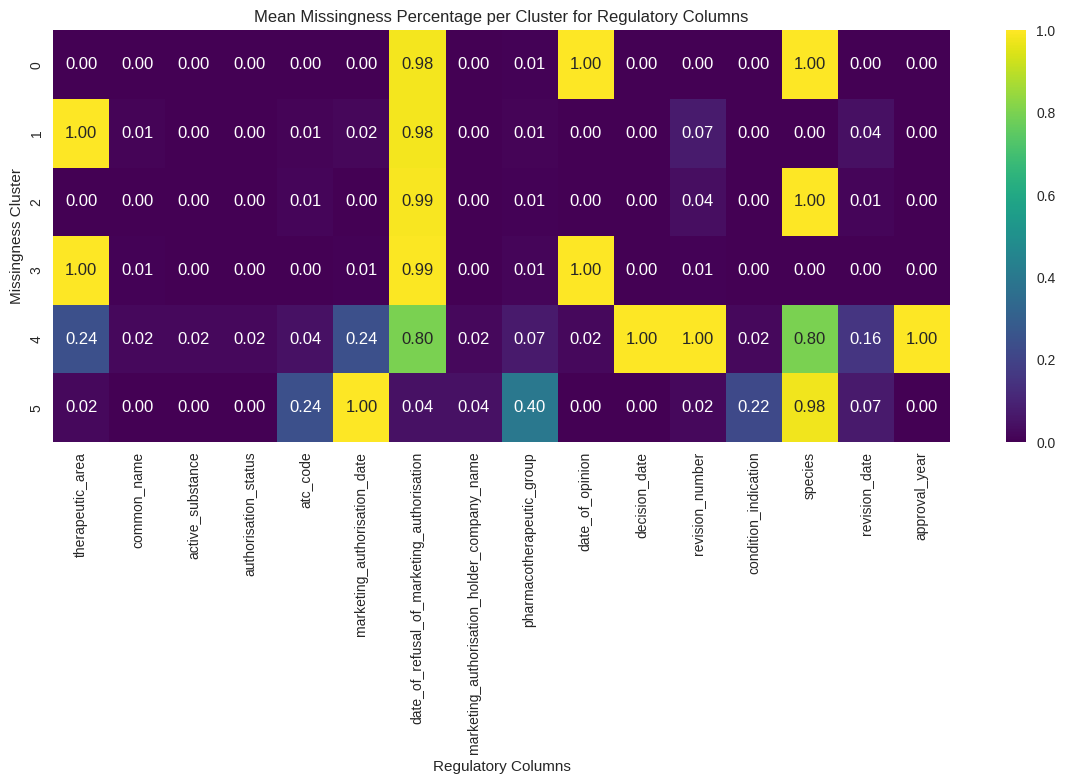

In [194]:
plt.figure(figsize=(12, 8))
sns.heatmap(mean_missingness_per_cluster, annot=True, cmap='viridis', fmt='.2f')
plt.title('Mean Missingness Percentage per Cluster for Regulatory Columns')
plt.xlabel('Regulatory Columns')
plt.ylabel('Missingness Cluster')
plt.tight_layout()
plt.show()

#Human vs. Animal Drugs - Brian

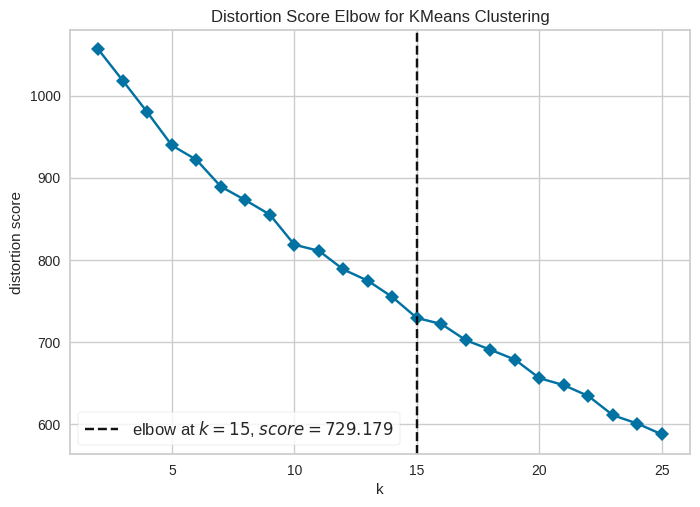

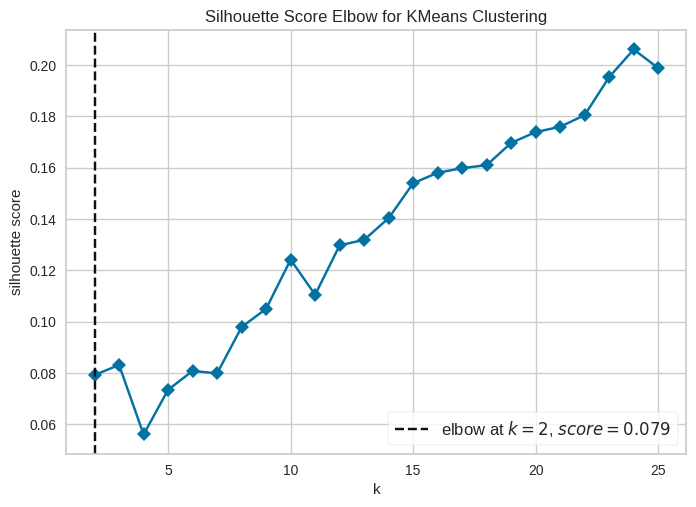

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [195]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state = 999, n_init = 10)

visualizer_inertia = KElbowVisualizer(model, k = (2,26), metric = 'distortion', timings = False)
visualizer_inertia.fit(X_svd)
visualizer_inertia.show()

visualizer_silhouette = KElbowVisualizer(model, k=(2, 26), metric='silhouette', timings=False)
visualizer_silhouette.fit(X_svd)
visualizer_silhouette.show()

In [196]:
# run K-Means again with set optimal K
optimal_k = 16

kmeans_final = KMeans(n_clusters = optimal_k, random_state = 999, n_init = 10)
kmeans_final.fit(X_svd)
drugs['cluster_label'] = kmeans_final.labels_

print(drugs['cluster_label'].value_counts())

cluster_label
6     356
1     229
2     188
3     174
5     160
9     157
0     136
13    118
7      83
4      80
10     70
14     68
15     51
8      49
12     47
11     22
Name: count, dtype: int64


In [197]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
import plotly.express as px

tsne = TSNE(n_components=3, random_state=999, init='pca', learning_rate='auto')
X_tsne_3d = tsne.fit_transform(X_svd)

# Upon initial creation of the cluster visualization, some condition_indication texts would be too long, obscuring the medicine_name.
# Created a new column 'short_indication' to cap some of the texts for a clearer visual experience
drugs['short_indication'] = drugs['condition_indication'].apply(
    lambda x: str(x)[:100] + "..." if len(str(x)) > 100 else str(x)
)

drugs['tsne_x'] = X_tsne_3d[:, 0]
drugs['tsne_y'] = X_tsne_3d[:, 1]
drugs['tsne_z'] = X_tsne_3d[:, 2]

fig = px.scatter_3d(
    drugs,
    x='tsne_x',
    y='tsne_y',
    z='tsne_z',
    color='cluster_label',
    hover_name='medicine_name',  # Shows drug name when you hover
    hover_data={
        'short_indication': True,
        'tsne_x': False,
        'tsne_y': False,
        'tsne_z': False,
        'cluster_label': True
    },
    color_continuous_scale='Turbo',
    title='Interactive 3D Semantic Landscape (k=16)'
)

# Update marker size for better visibility
fig.update_traces(marker=dict(size=3, opacity=0.7))

fig.show()

In [198]:
# For the visualization step, we used X_svd for added clarity in visualizing the clusters.
# We don't need the dimensionality reduction when looking at the plain text words of these clusters
# As such, we will use X_tfidf to look at the top keywords for each cluster

def get_top_keywords(n_terms):
    """This function returns the top keywords for each centroid of the KMeans"""
    drugs_clusters = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out()) # Changed vectorizer to tfidf #Why
    drugs_clusters['label'] = kmeans_final.labels_

    # group by cluster label, and get the 'mean' of each word.
    cluster_means = drugs_clusters.groupby('label').mean()

    for i, row in cluster_means.iterrows():
        print(f"\nCluster {i}:")
        top_words = row.sort_values(ascending=False).head(n_terms)
        print(", ".join(top_words.index))

print(f"--- Top Keywords for Each Cluster (k={optimal_k}) ---")
get_top_keywords(16)

--- Top Keywords for Each Cluster (k=16) ---

Cluster 0:
immunisation, reduce, active, clinical, sign, cause, virus, immunity, week, mortality, prevent, infection, lesion, age, vaccination, month

Cluster 1:
use, official, infection, cause, prevention, influenza, product, appropriate, flea, agent, age, treatment, infestation, indicate, adult, year

Cluster 2:
year, age, adolescent, treatment, child, adult, antiretroviral, indicate, old, patient, hivminus1, combination, 12, seizure, therapy, hiv

Cluster 3:
cancer, metastatic, advanced, treatment, patient, cell, indicate, locally, combination, chemotherapy, lung, breast, adult, monotherapy, carcinoma, therapy

Cluster 4:
metformin, control, glycaemic, diet, exercise, mellitus, diabete, combination, type, adjunct, patient, adequate, insulin, sulphonylurea, intolerance, tolerate

Cluster 5:
treatment, adult, indicate, episode, disorder, patient, hypertension, symptom, require, in, secondary, moderate, severe, respond, therapy, acid

Clust

category       human  veterinary
cluster_label                   
0                  5         131
1                173          56
2                188           0
3                173           1
4                 80           0
5                151           9
6                352           4
7                 83           0
8                 49           0
9                156           1
10                69           1
11                22           0
12                46           1
13                41          77
14                67           1
15                51           0


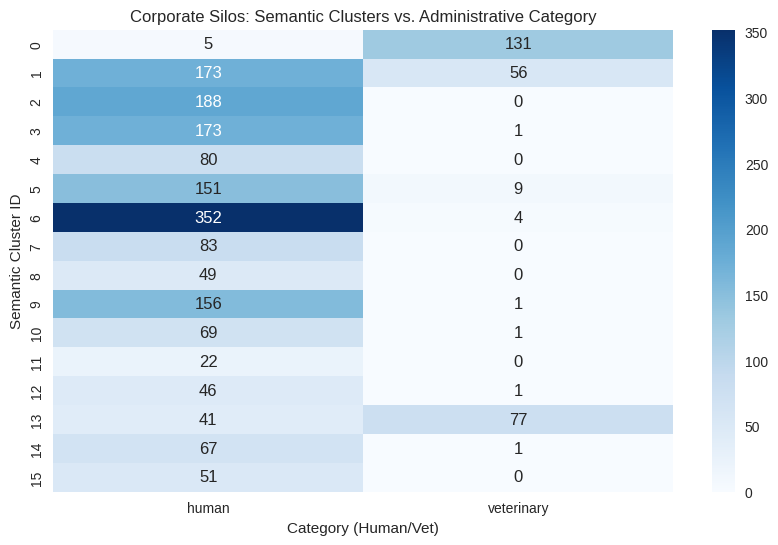

In [199]:
# counts of how many human vs. vet drugs are in each cluster

cluster_species_crosstab = pd.crosstab(drugs['cluster_label'], drugs['category'])
print(cluster_species_crosstab)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_species_crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Corporate Silos: Semantic Clusters vs. Administrative Category')
plt.xlabel('Category (Human/Vet)')
plt.ylabel('Semantic Cluster ID')
plt.show()

In [200]:
# calcuating centroids
center_x = drugs['tsne_x'].mean()
center_y = drugs['tsne_y'].mean()
center_z = drugs['tsne_z'].mean()

# calculating euclidean distance from centroid
drugs['distance_from_center'] = np.sqrt(
    (drugs['tsne_x'] - center_x)**2 +
    (drugs['tsne_y'] - center_y)**2 +
    (drugs['tsne_z'] - center_z)**2
)
outliers = drugs.sort_values('distance_from_center', ascending=False).head(10)

print("--- Insight B: The 'Blue Ocean' Outliers ---")
for index, row in outliers.iterrows():
    print(f"Drug: {row['medicine_name']}")
    print(f"Condition: {row['condition_indication'][:100]}...")
    print(f"Cluster: {row['cluster_label']}")
    print("-" * 30)

--- Insight B: The 'Blue Ocean' Outliers ---
Drug: Steglatro
Condition: Steglatro is indicated in adults aged 18 years and older with type 2 diabetes mellitus as an adjunct...
Cluster: 4
------------------------------
Drug: CaniLeish
Condition: For the active immunisation of Leishmania-negative dogs from six months of age to reduce the risk to...
Cluster: 0
------------------------------
Drug: Neulasta
Condition: Reduction in the duration of neutropenia and the incidence of febrile neutropenia in patients treate...
Cluster: 11
------------------------------
Drug: Pelgraz
Condition: Reduction in the duration of neutropenia and the incidence of febrile neutropenia in patients treate...
Cluster: 11
------------------------------
Drug: Neupopeg
Condition: Reduction in the duration of neutropenia and the incidence of febrile neutropenia in patients treate...
Cluster: 11
------------------------------
Drug: Zomarist
Condition: Zomarist is indicated as an adjunct to diet and exercise to impro

#Building Outcome Profiles - Rahul

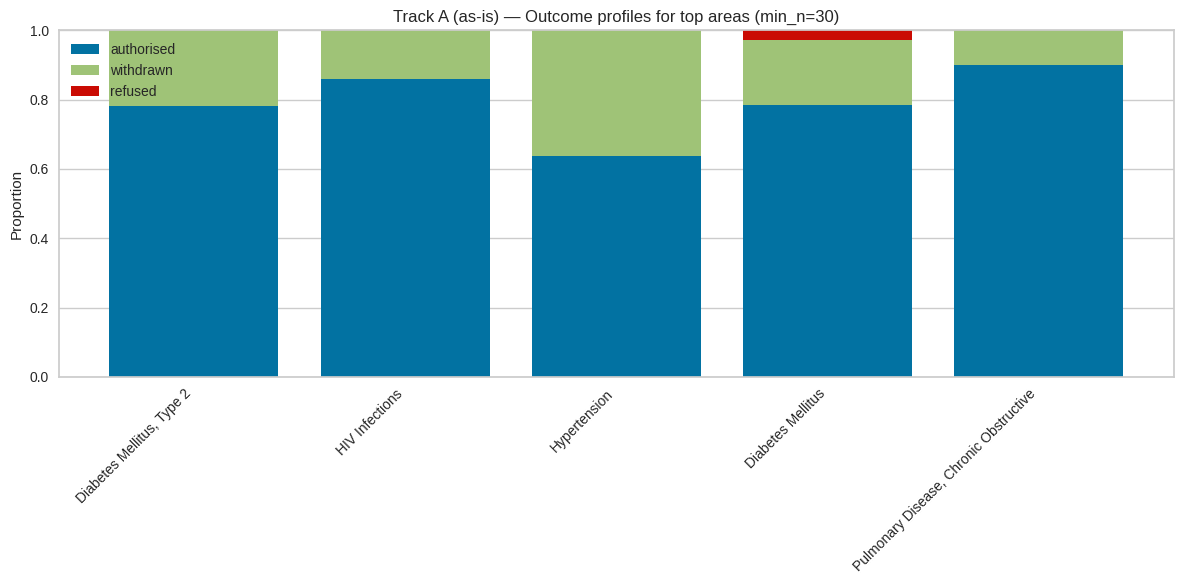

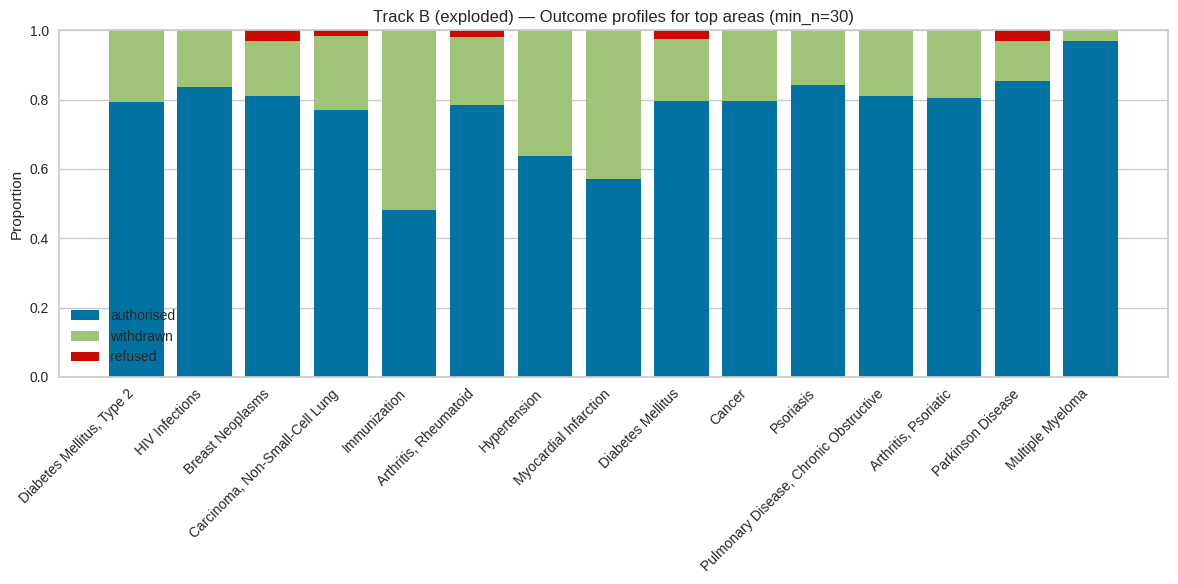

In [201]:
import os

def plot_stacked_profiles(profiles: pd.DataFrame, title: str, top_k: int = 15, save_path: str = None):
    sub = profiles.head(top_k).copy()

    areas = sub.index.tolist()
    p_auth = sub["p_authorised"].values
    p_with = sub["p_withdrawn"].values
    p_ref  = sub["p_refused"].values

    x = np.arange(len(areas))

    plt.figure(figsize=(12, 6))
    plt.bar(x, p_auth, label="authorised")
    plt.bar(x, p_with, bottom=p_auth, label="withdrawn")
    plt.bar(x, p_ref, bottom=p_auth + p_with, label="refused")
    plt.xticks(x, areas, rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Proportion")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

FIG_DIR = '.' # Define a default directory if not defined elsewhere

plot_stacked_profiles(
    profiles_A,
    title=f"Track A (as-is) — Outcome profiles for top areas (min_n={MIN_N})",
    top_k=min(15, len(profiles_A)),
    save_path=os.path.join(FIG_DIR, f"stacked_profiles_A_min{MIN_N}.png")
)

plot_stacked_profiles(
    profiles_B,
    title=f"Track B (exploded) — Outcome profiles for top areas (min_n={MIN_N})",
    top_k=min(15, len(profiles_B)),
    save_path=os.path.join(FIG_DIR, f"stacked_profiles_B_min{MIN_N}.png")
)

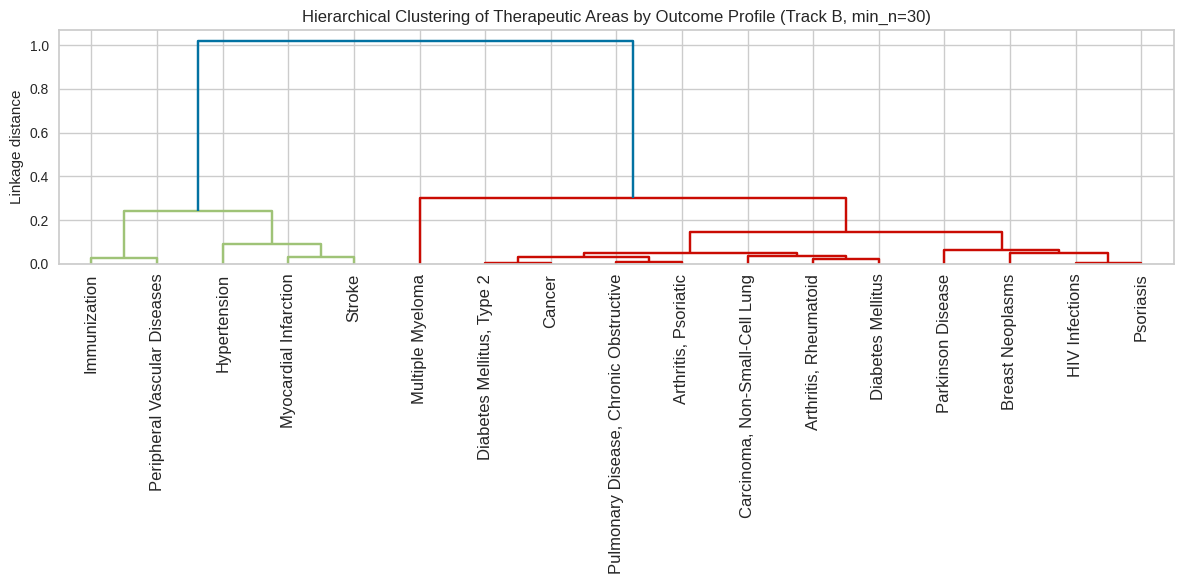

In [202]:
from scipy.cluster.hierarchy import linkage, dendrogram

profiles = profiles_B.copy()   # mainline choice
assert profiles.shape[0] >= 10, "Too few high-volume areas — lower MIN_N or revisit preprocessing."

# Feature matrix: outcome proportions per therapeutic area
X = profiles[["p_authorised", "p_withdrawn", "p_refused"]].values
areas = profiles.index.tolist()

# Hierarchical clustering (Ward linkage)
Z = linkage(X, method="ward")

# Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=areas, leaf_rotation=90)
plt.title(f"Hierarchical Clustering of Therapeutic Areas by Outcome Profile (Track B, min_n={MIN_N})")
plt.ylabel("Linkage distance")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"dendrogram_B_min{MIN_N}.png"), dpi=200, bbox_inches="tight")
plt.show()

#Alex's Medicine EDA

##Evaluate KMeans k range

In [203]:
from sklearn.preprocessing import StandardScaler

flag_cols = [
    "patient_safety", "additional_monitoring", "generic", "biosimilar",
    "conditional_approval", "exceptional_circumstances",
    "accelerated_assessment", "orphan_medicine"
]

date_cols = [
    "marketing_authorisation_date",
    "date_of_refusal_of_marketing_authorisation",
    "date_of_opinion",
    "decision_date",
    "first_published",
    "revision_date"
]

for c in date_cols:
    if c in drugs.columns:
        drugs[c] = pd.to_datetime(drugs[c], errors="coerce", dayfirst=True)

# Years from your existing parsed datetime columns
drugs["auth_year"] = drugs["marketing_authorisation_date"].dt.year
drugs["decision_year"] = drugs["decision_date"].dt.year

# --- Numeric: flags + years ---
X_num = drugs[flag_cols + ["auth_year","decision_year"]].copy()

# convert years to numeric safely
for c in ["auth_year","decision_year"]:
    X_num[c] = pd.to_numeric(X_num[c], errors="coerce")

# fill missing (common for decision_year/auth_year if date missing)
X_num = X_num.fillna(X_num.median(numeric_only=True))

# standardize numeric block
X_num_scaled = StandardScaler().fit_transform(X_num)

# --- Final feature matrix: concatenate text + numeric ---
X = np.hstack([X_svd, X_num_scaled])
print("Final X shape:", X.shape)

Final X shape: (1988, 60)


In [204]:
from sklearn.metrics import silhouette_score

inertias = []
sils = []
Ks = range(2, 26)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, labels))

print(pd.DataFrame({"k": list(Ks), "inertia": inertias, "silhouette": sils}))

     k       inertia  silhouette
0    2  18776.407066    0.165227
1    3  16627.822953    0.202642
2    4  14777.188940    0.236590
3    5  12111.905639    0.318568
4    6  10210.103611    0.353007
5    7   8279.098236    0.370038
6    8   6572.107680    0.416254
7    9   5253.059369    0.438231
8   10   4248.875288    0.466350
9   11   3612.351905    0.398484
10  12   3447.518324    0.390264
11  13   3272.077982    0.395395
12  14   3211.579103    0.361395
13  15   3072.184939    0.338393
14  16   3018.818729    0.308631
15  17   2857.925737    0.309078
16  18   2693.917445    0.308655
17  19   2531.205445    0.310321
18  20   2366.606898    0.311071
19  21   2230.410104    0.273683
20  22   2183.210275    0.280448
21  23   2016.418829    0.281483
22  24   1967.995455    0.281814
23  25   1936.691989    0.282472


In [205]:
best_k = Ks[int(np.argmax(sils))]
best_k

10

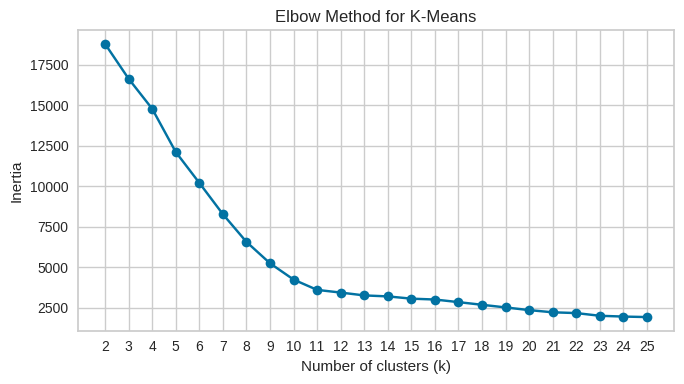

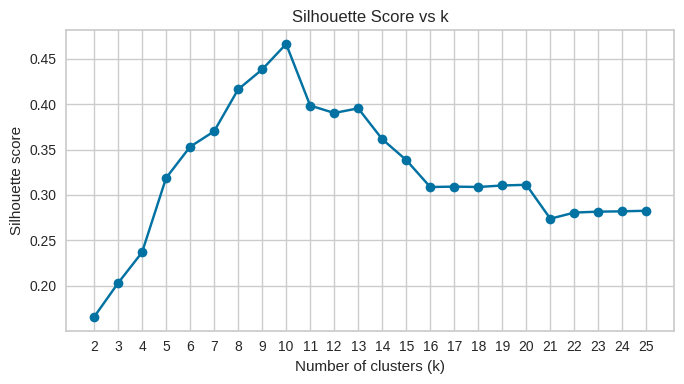

In [206]:
plt.figure(figsize=(7,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(Ks))
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot silhouette
plt.figure(figsize=(7,4))
plt.plot(Ks, sils, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.xticks(list(Ks))
plt.grid(True)
plt.tight_layout()
plt.show()

In [207]:
k = best_k  # or set manually like 4 or 5 if you want interpretability
km = KMeans(n_clusters=k, random_state=42, n_init="auto")
drugs["kmeans_cluster"] = km.fit_predict(X)

drugs["kmeans_cluster"].value_counts().sort_index()

,count
kmeans_cluster,
0,315
1,173
2,43
3,191
4,47
5,46
6,11
7,92
8,970


In [208]:
drugs[drugs["kmeans_cluster"] == 1][flag_cols].mean().round(3)

,0
patient_safety,0.0
additional_monitoring,0.0
generic,0.0
biosimilar,0.0
conditional_approval,0.0
exceptional_circumstances,0.0
accelerated_assessment,0.0
orphan_medicine,0.0


In [209]:
drugs[drugs["kmeans_cluster"] == 6][flag_cols + ["condition_indication_cleaned"]].head()

,patient_safety,additional_monitoring,generic,biosimilar,conditional_approval,exceptional_circumstances,accelerated_assessment,orphan_medicine,condition_indication_cleaned
59,True,True,False,False,False,False,False,False,comirnaty 30 microgramsordose concentrate disp...
62,True,True,False,False,False,False,False,False,cibinqo indicate treatment moderateminustominu...
109,True,False,False,False,False,False,False,False,rheumatoid arthritisbaricitinib indicate treat...
122,True,True,False,False,False,False,False,False,spikevax indicate active immunisation prevent ...
130,True,True,False,False,False,False,False,False,vaxzevria indicate active immunisation prevent...


In [210]:
drugs.groupby("kmeans_cluster")["orphan_medicine"].mean().sort_values(ascending=False)

,orphan_medicine
kmeans_cluster,
9,1.000000
4,0.553191
2,0.418605
5,0.391304
1,0.000000
0,0.000000
3,0.000000
6,0.000000
7,0.000000


In [211]:
cluster_summary = (
    drugs.groupby("kmeans_cluster")[flag_cols]
      .mean()
      .round(3)
)

cluster_summary

,patient_safety,additional_monitoring,generic,biosimilar,conditional_approval,exceptional_circumstances,accelerated_assessment,orphan_medicine
kmeans_cluster,,,,,,,,
0,0.0,0.013,1.0,0.0,0.000,0.000,0.000,0.000
1,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000
2,0.0,0.791,0.0,0.0,0.000,1.000,0.000,0.419
3,0.0,1.000,0.0,0.0,0.000,0.000,0.000,0.000
4,0.0,0.915,0.0,0.0,1.000,0.000,0.021,0.553
5,0.0,0.174,0.0,0.0,0.000,0.109,1.000,0.391
6,1.0,0.818,0.0,0.0,0.091,0.000,0.091,0.000
7,0.0,0.522,0.0,1.0,0.000,0.000,0.000,0.000
8,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000


In [212]:
overall_flags = drugs[flag_cols].mean()

(cluster_summary - overall_flags).round(3)

,patient_safety,additional_monitoring,generic,biosimilar,conditional_approval,exceptional_circumstances,accelerated_assessment,orphan_medicine
kmeans_cluster,,,,,,,,
0,-0.006,-0.182,0.842,-0.046,-0.024,-0.024,-0.024,-0.081
1,-0.006,-0.195,-0.158,-0.046,-0.024,-0.024,-0.024,-0.081
2,-0.006,0.596,-0.158,-0.046,-0.024,0.976,-0.024,0.338
3,-0.006,0.805,-0.158,-0.046,-0.024,-0.024,-0.024,-0.081
4,-0.006,0.720,-0.158,-0.046,0.976,-0.024,-0.003,0.472
5,-0.006,-0.021,-0.158,-0.046,-0.024,0.085,0.976,0.310
6,0.994,0.623,-0.158,-0.046,0.067,-0.024,0.067,-0.081
7,-0.006,0.327,-0.158,0.954,-0.024,-0.024,-0.024,-0.081
8,-0.006,-0.195,-0.158,-0.046,-0.024,-0.024,-0.024,-0.081


##PCA projection

In [213]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

drugs["pca1"] = X_2d[:, 0]
drugs["pca2"] = X_2d[:, 1]

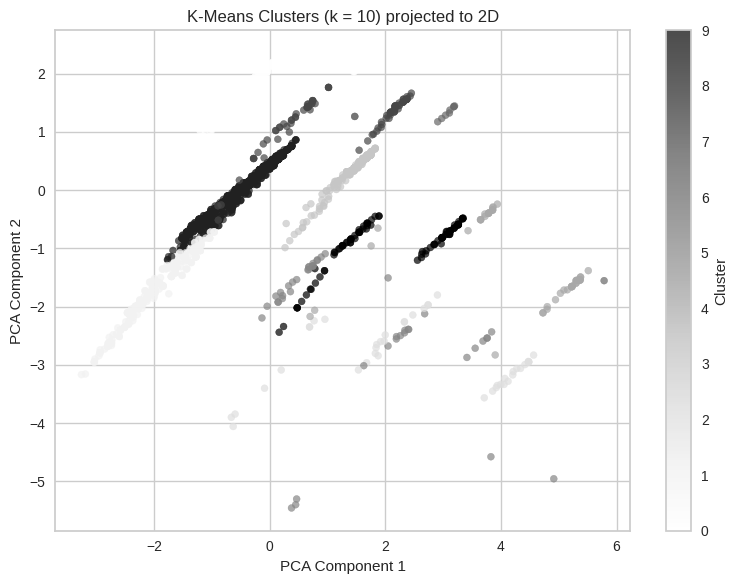

In [214]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    drugs["pca1"],
    drugs["pca2"],
    c=drugs["kmeans_cluster"],
    s=25,
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (k = 10) projected to 2D")

plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

In [215]:
cluster_profile = drugs.groupby("kmeans_cluster")[flag_cols + ["auth_year","decision_year"]]\
                    .mean().round(3)
cluster_profile

,patient_safety,additional_monitoring,generic,biosimilar,conditional_approval,exceptional_circumstances,accelerated_assessment,orphan_medicine,auth_year,decision_year
kmeans_cluster,,,,,,,,,,
0,0.0,0.013,1.0,0.0,0.000,0.000,0.000,0.000,2014.446,2020.800
1,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000,2002.353,2009.133
2,0.0,0.791,0.0,0.0,0.000,1.000,0.000,0.419,2013.628,2020.220
3,0.0,1.000,0.0,0.0,0.000,0.000,0.000,0.000,2018.168,2021.486
4,0.0,0.915,0.0,0.0,1.000,0.000,0.021,0.553,2018.936,2021.523
5,0.0,0.174,0.0,0.0,0.000,0.109,1.000,0.391,2013.870,2021.065
6,1.0,0.818,0.0,0.0,0.091,0.000,0.091,0.000,2019.455,2022.273
7,0.0,0.522,0.0,1.0,0.000,0.000,0.000,0.000,2016.697,2021.057
8,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000,2009.740,2021.026


In [216]:
terms = vectorizer.get_feature_names_out()
X_tfidf_dense = X_tfidf  # sparse

top_terms_per_cluster = {}

for cl in sorted(drugs["kmeans_cluster"].unique()):
    idx = drugs.index[drugs["kmeans_cluster"] == cl].to_numpy()
    # mean TF-IDF vector for the cluster
    mean_vec = X_tfidf_dense[idx].mean(axis=0)
    mean_vec = np.asarray(mean_vec).ravel()
    top_idx = mean_vec.argsort()[-12:][::-1]
    top_terms_per_cluster[cl] = terms[top_idx]

top_terms_per_cluster

{np.int32(0): array(['treatment', 'patient', 'adult', 'indicate', 'combination',
        'therapy', 'disease', 'prevention', 'accord', 'acute', 'age',
        'cancer'], dtype=object),
 np.int32(1): array(['treatment', 'patient', 'indicate', 'section', 'infection',
        'acute', 'therapy', 'hypertension', 'minus', 'cause', 'use',
        'immunisation'], dtype=object),
 np.int32(2): array(['patient', 'influenza', 'syndrome', 'indicate', 'treatment',
        'deficiency', 'age', 'adult', 'prophylaxis', 'official', 'year',
        'old'], dtype=object),
 np.int32(3): array(['adult', 'indicate', 'treatment', 'patient', 'disease', 'chronic',
        'year', 'combination', 'age', 'therapy', 'official', 'cancer'],
       dtype=object),
 np.int32(4): array(['patient', 'adult', 'monotherapy', 'treatment', 'indicate', 'cell',
        'advanced', 'inhibitor', 'therapy', 'prior', 'mutation',
        'refractory'], dtype=object),
 np.int32(5): array(['indicate', 'treatment', 'virus', 'age', 'ad

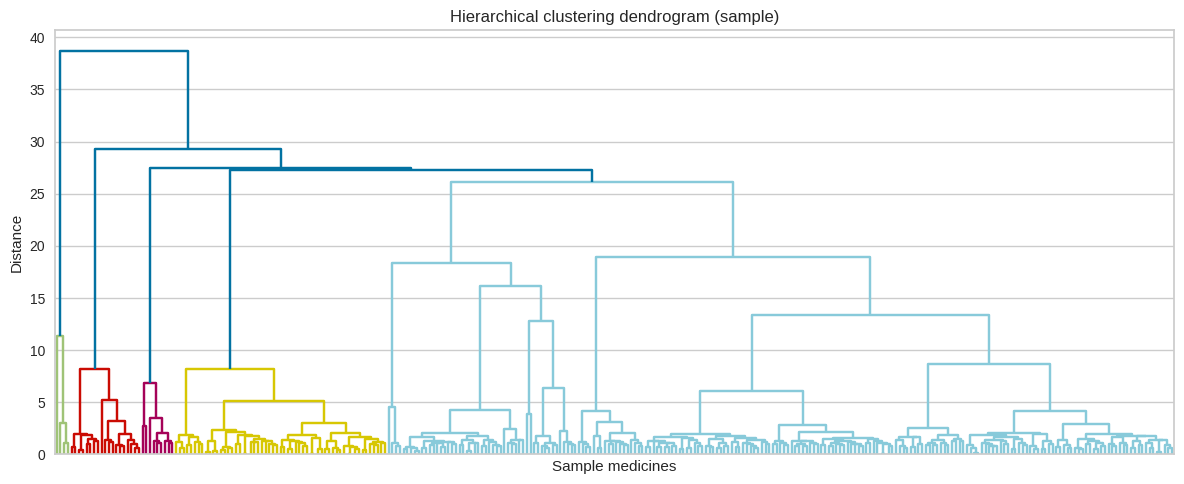

In [217]:
from scipy.cluster.hierarchy import linkage, dendrogram

sample_n = min(300, len(drugs))
sample_idx = drugs.sample(sample_n, random_state=42).index
X_sample = X[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Hierarchical clustering dendrogram (sample)")
plt.xlabel("Sample medicines")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [218]:
from scipy.cluster.hierarchy import fcluster

# Cut the dendrogram at k=10 clusters
hier_labels = fcluster(Z, t=10, criterion="maxclust")

df.loc[sample_idx, "hier_cluster"] = hier_labels
df.loc[sample_idx, "hier_cluster"].value_counts().sort_index()

,count
hier_cluster,
1.0,4
2.0,19
3.0,9
4.0,57
5.0,4
6.0,33
7.0,14
8.0,18
9.0,67
